In [7]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

PALETTE = {
    "Group": '#63859c',     
    "Pseudo": '#b3b3b3'
}

HUE_ORDER = ["Group", "Pseudo"]

df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/nearest_neighbour.csv')
df1['condition'] = 'Group'

df2 = pd.read_feather('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed-pseudo/nearest_neighbour.feather')
df2['condition'] = 'Pseudo'

df = pd.concat([df1, df2], ignore_index=True)

bins = list(range(0, 90, 1))  # [0, 10, 20, ..., 100]
df['bin'] = pd.cut(df['head_distance'], bins, include_lowest=True) #body-body ; closest_node_distance ; head_distance
df['bin_right'] = df['bin'].apply(lambda x: x.right).astype(float)

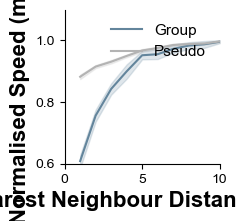

In [8]:
baseline = (
    df[(df['bin_right'] >= 10) & (df['bin_right'] < 20)]
      .groupby(['condition', 'filename'], as_index=False)['speed_tail']
      .mean()
      .rename(columns={'speed_tail': 'mean_speed_10_20'})
)

df = df.merge(baseline, on=['condition', 'filename'], how='left')
df = df.dropna(subset=['mean_speed_10_20']).copy()
df['speed_norm'] = df['speed_tail'] / df['mean_speed_10_20']


df_plot = (
    df.groupby(['condition', 'filename', 'bin_right'], as_index=False)['speed_norm']
      .mean()
)

df_plot = df_plot[df_plot['bin_right'] <= 10]  # Filter to only include bins up to 10


plt.figure(figsize=(2, 2))

ax = sns.lineplot(
    data=df_plot,
    x='bin_right',
    y='speed_norm',
    hue='condition', errorbar=('ci', 95), palette=PALETTE, hue_order=HUE_ORDER)

# plt.ylim(0,1.1)
# plt.ylim(0, 1.1)
plt.ylim(0.6, 1.1)
plt.xlim(0,10)
plt.xlabel('Nearest Neighbour Distance (mm)', fontsize=16, fontweight='bold')
plt.ylabel('Normalised Speed (mm/s)', fontsize=16, fontweight='bold')
plt.subplots_adjust(wspace=0.3, hspace=0.4)
# plt.suptitle('Speed vs Nearest Neighour Distance From Head', fontsize=16, fontweight='bold')

ax.legend(
    title=None,
    frameon=False,
    fontsize=11,
    loc='upper right'
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color('black')


sns.despine()

plt.show()

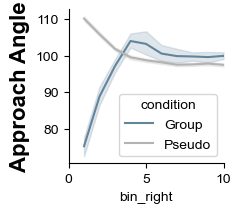

In [11]:
df_plot = (
    df.groupby(['condition', 'filename', 'bin_right'], as_index=False)['approach_angle']
      .mean()
)

df_plot = df_plot[df_plot['bin_right'] <= 10]  # Filter to only include bins up to 10


plt.figure(figsize=(2, 2))

sns.lineplot(
    data=df_plot,
    x='bin_right',
    y='approach_angle',
    hue='condition', errorbar=('ci', 95), palette=PALETTE, hue_order=HUE_ORDER)

# plt.ylim(0,1.1)
# plt.ylim(0, 1.1)
# plt.ylim(0.6, 1.1)
plt.xlim(0,10)
plt.ylabel('Approach Angle', fontsize=16, fontweight='bold')
plt.subplots_adjust(wspace=0.3, hspace=0.4)
# plt.suptitle('Speed vs Nearest Neighour Distance From Head', fontsize=16, fontweight='bold')

ax.legend(
    title=None,
    frameon=False,
    fontsize=11,
    loc='upper right'
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_color('black')


sns.despine()

plt.show()